In [6]:
import pandas as pd
import numpy as np
from copy import deepcopy

import string
import re

import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm

#!pip install py_stringsimjoin
import py_stringsimjoin as ssj
#!pip install py_stringmatching
import py_stringmatching as sm

<a id="introduzione"></a>
<a id="introduzione"></a>
<a id="introduzione"></a>
<a id="introduzione"></a>
<a id="introduzione"></a>
<a id="introduzione"></a>
<a id="introduzione"></a>
<a id="introduzione"></a>
# Introduzione

Questo Notebook riassume tutto il processo di **Schema Matching** e **Schema  Integration** (Bottom-up e Top-Down)

Nella prima sezione **Schem Matching** sono riportate le funzioni e strutture che vengono poi utilizzate 
nella funzione  **CalcoloMatchingTable** che definisce il metodo di matching calcolando la **Match Table** tra due tabelle. Questa funzione verrà poi utilizza nei metodi di Schema Integration.



<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
<a id="schema-matching"></a>
# Schema Matching

<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
<a id="to-sim-table-e-to-sim-matrix"></a>
## to_sim_table e to_sim_matrix

In [7]:
def sim_table(TableA:pd.DataFrame, TableB:pd.DataFrame):
    A = pd.DataFrame({"A": TableA.columns})
    B = pd.DataFrame({"B": TableB.columns})
    S = A.assign(key=1).merge(B.assign(key=1), on="key").drop("key", axis=1)
    return S

def random_sim_table(TableA:pd.DataFrame, TableB:pd.DataFrame):
    S = sim_table(TableA, TableB)
    S["sim"] = np.random.rand(len(S))
    return S

def to_sim_table(SimMatrix:pd.DataFrame):
    return SimMatrix.stack().reset_index(name="sim")

def to_sim_matrix(SimTable:pd.DataFrame):
    return SimTable.pivot(index="A", columns="B", values="sim") \
              .rename_axis(None, axis=1).rename_axis(None, axis=0)

def string_preprocess(s:str, char:str=string.punctuation, word:list=[]):
    if type(s) is str:
        s = s.lower()
        for c in char:
            s = s.replace(c, " ")
        for w in word:
            s = s.replace(w, " ")
    else:
        s = str(s)
    s = re.sub(" +", " ", s)
    return s.strip()

<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
<a id="label-based"></a>
## Label-Based 

In [8]:
def levenshtein_sim(row:pd.Series):
    lev = sm.Levenshtein()
    return lev.get_sim_score(
            string_preprocess(row["A"]),
            string_preprocess(row["B"])
        )

def levenshtein_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(levenshtein_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# Jaro
def jaro_sim(row:pd.Series):
    jaro = sm.Jaro()
    return jaro.get_sim_score(
            string_preprocess(row["A"]),
            string_preprocess(row["B"])
        )

def jaro_label_based_similarity(TableA:pd.DataFrame,TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(jaro_sim, axis=1)                   
    return C


# Jaccard
def jaccard_sim(row:pd.Series):
    jac=sm.Jaccard()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return jac.get_sim_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
    )

def jaccard_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(jaccard_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# OverlapCoefficient
def OC_sim(row:pd.Series):
    oc = sm.OverlapCoefficient()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return oc.get_sim_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
    )

def OC_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(OC_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# JaroWinkler
def JaroWinkler_sim(row:pd.Series):
    jw = sm.JaroWinkler()
    return jw.get_sim_score(
            string_preprocess(row["A"]),
            string_preprocess(row["B"])
        )

def JaroWinkler_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(JaroWinkler_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# MongeElkan
#Secondary similarity function. This is expected to be a sequence-based similarity measure 
#(defaults to Jaro-Winkler similarity measure).
def MongeElkan_sim(row:pd.Series):
    me = sm.MongeElkan()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return me.get_raw_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
    )


def MongeElkan_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(MongeElkan_sim, axis=1)
    return C.sort_values("sim", ascending=False)

<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
<a id="value-overlap-jaccard-generalized-jaccard"></a>
## Value Overlap : Jaccard & Generalized Jaccard

In [9]:
def jaccard_sim_value(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame):
    j = sm.Jaccard()
    return j.get_raw_score(
            TableA[row["A"]].apply(string_preprocess).tolist(),
            TableB[row["B"]].apply(string_preprocess).tolist()
        )

def jaccard_value_overlap_sim(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(jaccard_sim_value, args=(TableA, TableB), axis=1)
    return C.sort_values("sim", ascending=False)

def generalized_sim_value(row:pd.Series, TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    j = sm.GeneralizedJaccard(
            sim_func=sm.Levenshtein().get_sim_score,
            threshold=threshold
        )
    return j.get_raw_score(
            TableA[row["A"]].apply(string_preprocess).tolist(),
            TableB[row["B"]].apply(string_preprocess).tolist()
        )

def generalized_value_overlap_sim(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(generalized_sim_value, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim", ascending=False)

<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
<a id="value-overlap-extended-jaccard"></a>
## Value Overlap:   Extended Jaccard

In [10]:
def funzione_similarita_internaLEV(row:pd.Series): # Levenshtein
    lev = sm.Levenshtein()
    return lev.get_sim_score(
            string_preprocess(row["AX"]),
            string_preprocess(row["AY"])
        )

def extended_value_overlap_sim_LEV(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame, threshold:float):
    TX = TableA[[row["A"]]].applymap(string_preprocess).drop_duplicates()
    TY = TableB[[row["B"]]].applymap(string_preprocess).drop_duplicates()
    TX.columns=['AX']
    TY.columns=['AY']
    PCC = TX.drop_duplicates().assign(key=1).merge(TY.drop_duplicates().assign(key=1), on='key').drop(columns='key')
##    PCC = TX.drop_duplicates().merge(TY.drop_duplicates(), how='cross')
    PCC["SimJac"] = PCC.apply(funzione_similarita_internaLEV, axis=1)
    INTERSEZIONE =  PCC[PCC.SimJac>=threshold]
    SoloInAX=PCC.loc[~PCC['AX'].isin(INTERSEZIONE['AX'])][['AX']].drop_duplicates()
    SoloInAY=PCC.loc[~PCC['AY'].isin(INTERSEZIONE['AY'])][['AY']].drop_duplicates()
    return len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))

def value_overlap_extended_jaccard_LEV(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(extended_value_overlap_sim_LEV, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim",ascending=False)

def funzione_similarita_internaJaccard(row:pd.Series): # Jaccard
    jac=sm.Jaccard()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return jac.get_sim_score(
            tok.tokenize(string_preprocess(row["AX"])),
            tok.tokenize(string_preprocess(row["AY"])))

def extended_value_overlap_sim_JAC(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame, threshold:float):
    TX = TableA[[row["A"]]].applymap(string_preprocess).drop_duplicates()
    TY = TableB[[row["B"]]].applymap(string_preprocess).drop_duplicates()
    TX.columns=['AX']
    TY.columns=['AY']
    PCC = TX.drop_duplicates().assign(key=1).merge(TY.drop_duplicates().assign(key=1), on='key').drop(columns='key')
#    PCC = TX.drop_duplicates().merge(TY.drop_duplicates(), how='cross')
    PCC["SimJac"] = PCC.apply(funzione_similarita_internaJaccard, axis=1)
    INTERSEZIONE =  PCC[PCC.SimJac>=threshold]
    SoloInAX=PCC.loc[~PCC['AX'].isin(INTERSEZIONE['AX'])][['AX']].drop_duplicates()
    SoloInAY=PCC.loc[~PCC['AY'].isin(INTERSEZIONE['AY'])][['AY']].drop_duplicates()
    return len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))

def value_overlap_extended_jaccard_JAC(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(extended_value_overlap_sim_JAC, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim",ascending=False)

<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
<a id="value-overlap-string-similarity-join"></a>
## Value Overlap: String Similarity Join

In [11]:
def sim__join(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame, threshold:float):
    TX = TableA[[row["A"]]].applymap(string_preprocess).drop_duplicates()
    TY = TableB[[row["B"]]].applymap(string_preprocess).drop_duplicates()
    TX.columns=['AX']
    TY.columns=['AY']
    
    INTERSEZIONE  = ssj.jaccard_join(     TX, TY, # tabelle su cui effettuare il sim join
                                'AX', 'AY', # chiavi delle tabelle 
                                'AX', 'AY', # attributi di join
                                  sm.WhitespaceTokenizer(return_set=True),
                                  threshold=threshold, 
                                  show_progress=False,
                                  l_out_attrs=['AX'],  r_out_attrs=['AY']
                           )
    SoloInAX=TX.loc[~TX['AX'].isin(INTERSEZIONE['l_AX'])][['AX']].drop_duplicates()
    SoloInAY=TY.loc[~TY['AY'].isin(INTERSEZIONE['r_AY'])][['AY']].drop_duplicates()
    return len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))


def value_overlap_simjoin_jaccard(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(sim__join, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim",ascending=False)

<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
<a id="combined-approaches"></a>
## Combined Approaches

Consideriamo l'approccio *Ensemble* che combina la predizione
di più SimTable in una unica SimTable ottenuta tramite
 avg(), min(), or max() 

In [12]:
def max_sim_table(SimTableList:list):
    ST = pd.DataFrame(columns=["A","B","sim"])
    for x in SimTableList:
        ST = ST.append(x, ignore_index=True)
    return ST.groupby(["A","B"])["sim"].max().reset_index()

def min_sim_table(SimTableList:list):
    ST = pd.DataFrame(columns=["A","B","sim"])
    for x in SimTableList:
        ST = ST.append(x, ignore_index=True)
    return ST.groupby(["A","B"])["sim"].min().reset_index()

def avg_sim_table(SimTableList:list):
    ST = pd.DataFrame(columns=["A","B",'sim'])
    for x in SimTableList:
        ST = ST.append(x, ignore_index=True)
    return ST.groupby(["A","B"])["sim"].mean().reset_index()

<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
<a id="local-single-attribute-strategies"></a>
## Local Single Attribute Strategies

In [13]:
def thresholding(SimTable:pd.DataFrame, threshold:float):
    return SimTable[SimTable["sim"] > threshold].sort_values(["sim"], ascending=[False])
    
def top_K(SimTable:pd.DataFrame, K:int, AoB:str="A"):
    MT = deepcopy(SimTable)
    MT["pos"] = MT.sort_values(["sim"], ascending=[False]).groupby(AoB).cumcount()
    return MT[MT["pos"] < K].drop(columns=["pos"]).sort_values([AoB,"sim"], ascending=[True,False])

def top_1(SimTable:pd.DataFrame, AoB:str="A"):
    return top_K(SimTable, 1, AoB)

<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
<a id="global-matching"></a>
## Global Matching

Si considerano solo quelli *facili* da formulare, ovvero 
stable_marriage e simmetric_best_match

In [14]:
def stable_marriage(MatchTable:pd.DataFrame):
    MATCH = pd.DataFrame(columns=["A", "B", "sim"])
    MT = deepcopy(MatchTable)
    MT = MT.sort_values(["sim"], ascending=[False])
    while True:
        R = MT.loc[(~MT["A"].isin(MATCH["A"])) & (~MT["B"].isin(MATCH["B"]))]
        if len(R) == 0:
            break
        x = R.iloc[0,:]
        MATCH = MATCH.append(x, ignore_index=True)
    return MATCH

def simmetric_best_match(MatchTable:pd.DataFrame):
  CMT = deepcopy(MatchTable)

  CMT['A_RowNo'] = CMT.sort_values(['sim'], ascending=[False]) \
             .groupby(['A']) \
             .cumcount() + 1

  CMT['B_RowNo'] = CMT.sort_values(['sim'], ascending=[False]) \
             .groupby(['B']) \
             .cumcount() + 1

  return CMT[(CMT.A_RowNo==1) & (CMT.B_RowNo==1)].drop(columns=['A_RowNo', 'B_RowNo']).sort_values(['sim'], ascending=[False])

<a id="nuove-funzioni-di-schema-matching"></a>
<a id="nuove-funzioni-di-schema-matching"></a>
<a id="nuove-funzioni-di-schema-matching"></a>
<a id="nuove-funzioni-di-schema-matching"></a>
<a id="nuove-funzioni-di-schema-matching"></a>
<a id="nuove-funzioni-di-schema-matching"></a>
<a id="nuove-funzioni-di-schema-matching"></a>
<a id="nuove-funzioni-di-schema-matching"></a>
## *Nuove Funzioni* di schema matching

è possibile definire altre funzioni



In [15]:
def  Weighted_sum(dataframes, weights):
    if len(dataframes) < 2 or len(dataframes) != len(weights):
        raise ValueError("È necessario fornire almeno due DataFrame e i relativi pesi.")

    result_df = dataframes[0].copy()

    result_df["sim"] = result_df["sim"] * weights[0]

    for i in range(1, len(dataframes)):
        df = dataframes[i]
        weight = weights[i]

        result_df = pd.merge(result_df, df, on=["A", "B"], how="outer")

        result_df["sim"] = result_df.apply(lambda row: row["sim_x"] + row["sim_y"] * weight if not pd.isnull(row["sim_x"]) and not pd.isnull(row["sim_y"]) else row["sim_x"] if not pd.isnull(row["sim_x"]) else row["sim_y"] * weight, axis=1)

        result_df = result_df.drop(columns=["sim_x", "sim_y"])

    return result_df

<a id="funzione-calcolomatchingtable"></a>
<a id="funzione-calcolomatchingtable"></a>
<a id="funzione-calcolomatchingtable"></a>
<a id="funzione-calcolomatchingtable"></a>
<a id="funzione-calcolomatchingtable"></a>
<a id="funzione-calcolomatchingtable"></a>
<a id="funzione-calcolomatchingtable"></a>
<a id="funzione-calcolomatchingtable"></a>
## Funzione CalcoloMatchingTable

Definisce il metodo di matching calcolando la Match Table tra due tabelle

In [16]:
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

# Matching Methods: Qui si definiscono i Base Matcher da utilizzare; se ne possono aggiungere altri    
        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        SimTableB = jaro_label_based_similarity(TableL, TableR)
        #SimTableB = value_overlap_sim(GlobalSchema, Sources[y])
        SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.5)

# Combined Approaches: qui si definisce il combiner; se ne possono aggiungere altri    
        # SimTable = avg_sim_table([SimTableA,SimTableB,SimTableC])
        # SimTable = min_sim_table([SimTableA,SimTableB,SimTableC])
        SimTable = max_sim_table([SimTableA,SimTableB,SimTableC])

        # Weighted-sum
        SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )
        
# Generating Correspondences: dalla tabella di similarità alle corrispondenze

### Local Single Attribute Strategies:
        MatchTable= thresholding(SimTable, 0.6)

        #MatchTable = top_K(SimTable,2,'A')
        #MatchTable = top_K(MatchTable,2,'B')

        
### Global Mapping (si usano solo questi due metodi)
        #MatchTable = stable_marriage(MatchTable)
        MatchTable = simmetric_best_match(MatchTable)

        return MatchTable

<a id="valutazione"></a>
<a id="valutazione"></a>
<a id="valutazione"></a>
<a id="valutazione"></a>
<a id="valutazione"></a>
<a id="valutazione"></a>
<a id="valutazione"></a>
<a id="valutazione"></a>
# Valutazione

In [17]:
def Valuta(Gold:pd.DataFrame, Match:pd.DataFrame):
    Gold = Gold.iloc[:, :2].copy()
    Match = Match.iloc[:, :2].copy()
    Gold.columns = Match.columns = ['A', 'B']

    FOJ = Gold.merge(Match, how='outer', indicator=True) # full outer join between Gold and Match

    TP = FOJ[FOJ['_merge']=='both']
    FP = FOJ[FOJ['_merge']=='right_only']
    FN = FOJ[FOJ['_merge']=='left_only']

    if len(TP) == 0:
        return pd.DataFrame({
                'MT':[len(Match)],
                'TP':[len(TP)],
                'FP':[len(FP)],
                'FN':[len(FN)],
                'P':[round(0,4)],
                'R':[round(0,4)],
                'F':[round(0,4)]
            })
    else:
        P = len(TP)/(len(TP)+len(FP))
        R = len(TP)/(len(TP)+len(FN))
        F = 2 * P * R / ( P + R )
        return pd.DataFrame({
                'MT':[len(Match)],
                'TP':[len(TP)],
                'FP':[len(FP)],
                'FN':[len(FN)],
                'P':[round(P,4)],
                'R':[round(R,4)], 
                'F':[round(F,4)]
            })

def Vedi_Valuta(Gold:pd.DataFrame, Match:pd.DataFrame, metrics:str):
    Gold = Gold.iloc[:, :2].copy()
    Match = Match.iloc[:, :2].copy()
    Gold.columns = Match.columns = ['A', 'B']
    FOJ=pd.merge(Gold, Match, how='outer', indicator=True)

    TP=FOJ[FOJ['_merge']=='both']
    FP=FOJ[FOJ['_merge']=='right_only']
    FN=FOJ[FOJ['_merge']=='left_only']

    if metrics == 'FP' :
        return FP
    if metrics == 'TP' :
        return TP
    if metrics == 'FN' :
        return FN

<a id="esempio-valutazione"></a>
<a id="esempio-valutazione"></a>
<a id="esempio-valutazione"></a>
<a id="esempio-valutazione"></a>
<a id="esempio-valutazione"></a>
<a id="esempio-valutazione"></a>
<a id="esempio-valutazione"></a>
<a id="esempio-valutazione"></a>
## Esempio Valutazione

Come esempio di valutazione consideriamo quello *classico Bizer* con la match table data (è quella delle slide); viene dato  il *Gold Standard*   

In [18]:
# Esempio Bizer : due dataframe vuoti
DA = pd.DataFrame(columns=['ID','Name','Vorname','Alter'])
DB = pd.DataFrame(columns=['No','Name','FirstName','Age'])

## Match Table data
# Match Top1
VALORI = [
          ['A', 'B', ],
          ['ID', 'No'],
          ['Name', 'Name'],
          ['Vorname', 'Name'],
          ['Alter', 'Age'],
         ]
header = VALORI.pop(0)
MatchTable_Bizer = pd.DataFrame(VALORI, columns=header)
MatchTable_Bizer

# GoldStandard_Bizer
VALORI = [
          ['A', 'B', ],
          ['ID', 'No'],
          ['Name', 'Name'],
          ['Vorname', 'FirstName'],
          ['Alter', 'Age'],
         ]
header = VALORI.pop(0)
GoldStandard_Bizer = pd.DataFrame(VALORI, columns=header)
GoldStandard_Bizer

,A,B
0,ID,No
1,Name,Name
2,Vorname,FirstName
3,Alter,Age


In [19]:
DA

,ID,Name,Vorname,Alter


In [20]:
DB

,No,Name,FirstName,Age


In [21]:
GoldStandard_Bizer

,A,B
0,ID,No
1,Name,Name
2,Vorname,FirstName
3,Alter,Age


In [22]:
MatchTable_Bizer

,A,B
0,ID,No
1,Name,Name
2,Vorname,Name
3,Alter,Age


In [23]:
Valuta(GoldStandard_Bizer, MatchTable_Bizer)

,MT,TP,FP,FN,P,R,F
0,4,3,1,1,0.75,0.75,0.75


In [24]:
Vedi_Valuta(GoldStandard_Bizer, MatchTable_Bizer, 'FN')

,A,B,_merge
2,Vorname,FirstName,left_only


In [25]:
Vedi_Valuta(GoldStandard_Bizer, MatchTable_Bizer, 'FP')

,A,B,_merge
4,Vorname,Name,right_only


In [26]:
## Match Table data
# Match Top1
VALORI = [
          ['A', 'B', ]
         ]
header = VALORI.pop(0)
MatchTable_Bizer = pd.DataFrame(VALORI, columns=header)
MatchTable_Bizer

,A,B


In [27]:
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

# Matching Methods: Qui si definiscono i Base Matcher da utilizzare; se ne possono aggiungere altri    
        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        #SimTableA = jaro_label_based_similarity(TableL, TableR)
        #SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.5)

# Combined Approaches: qui si definisce il combiner; se ne possono aggiungere altri    
        # SimTable = avg_sim_table([SimTableA,SimTableB,SimTableC])
        # SimTable = min_sim_table([SimTableA,SimTableB,SimTableC])
        SimTable = max_sim_table([SimTableA])

        # Weighted-sum
        #SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )
        
# Generating Correspondences: dalla tabella di similarità alle corrispondenze

### Local Single Attribute Strategies:
        MatchTable= thresholding(SimTable, 0.2)

        #MatchTable = top_K(SimTable,2,'A')
        #MatchTable = top_K(MatchTable,2,'B')

        
### Global Mapping (si usano solo questi due metodi)
        #MatchTable = stable_marriage(MatchTable)
        #MatchTable = simmetric_best_match(MatchTable)

        return MatchTable

In [28]:
# Esempio Bizer : due dataframe vuoti
DA = pd.DataFrame(columns=['ID','Name','Vorname','Alter'])
DB = pd.DataFrame(columns=['No','Name','FirstName','Age'])
MT1=CalcoloMatchingTable(DA,DB)
MT1

,A,B,sim
10,Name,Name,1.000000
14,Vorname,Name,0.571429
13,Vorname,FirstName,0.555556
8,Name,Age,0.500000
9,Name,FirstName,0.444444
0,Alter,Age,0.400000
12,Vorname,Age,0.285714
11,Name,No,0.250000


In [29]:
Valuta(GoldStandard_Bizer, MT1)

,MT,TP,FP,FN,P,R,F
0,8,3,5,1,0.375,0.75,0.5


In [30]:
Vedi_Valuta(GoldStandard_Bizer, MT1, 'FP')

,A,B,_merge
4,Vorname,Name,right_only
5,Name,Age,right_only
6,Name,FirstName,right_only
7,Vorname,Age,right_only
8,Name,No,right_only


In [31]:
Vedi_Valuta(GoldStandard_Bizer, MT1, 'FN')

,A,B,_merge
0,ID,No,left_only


<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
<a id="top-down-data-integration"></a>
# Top-Down Data Integration

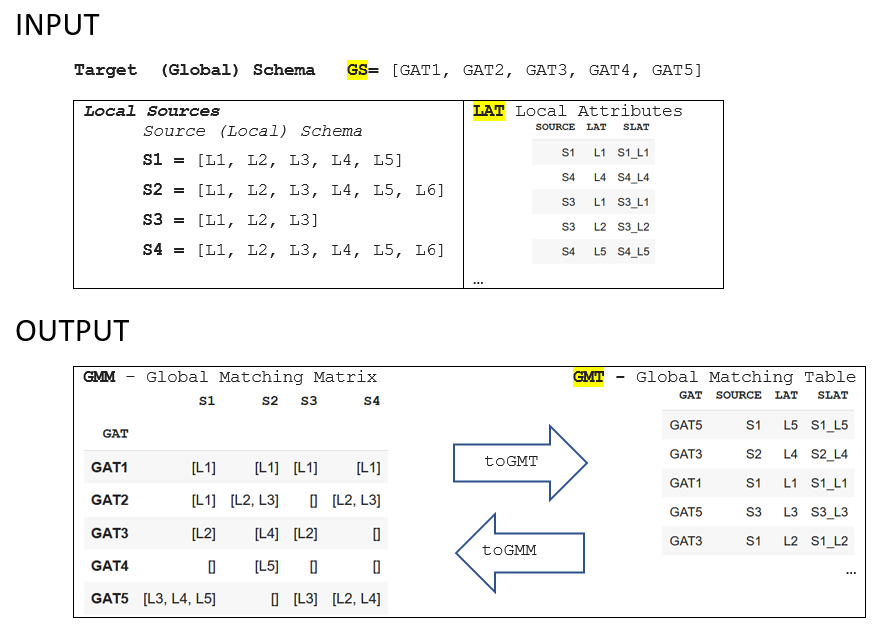



<a id="esempio-simbolico"></a>
<a id="esempio-simbolico"></a>
<a id="esempio-simbolico"></a>
<a id="esempio-simbolico"></a>
<a id="esempio-simbolico"></a>
<a id="esempio-simbolico"></a>
<a id="esempio-simbolico"></a>
<a id="esempio-simbolico"></a>
## Esempio Simbolico

Per spiegare questi concetti, consideriamo un Global schema GS e una Global Matching Table simboliche già date

In [32]:
# Esempio simbolico
GS= ['GAT1', 'GAT2', 'GAT3', 'GAT4','GAT5']
GMM = pd.DataFrame({'GAT': GS,
'S1': [['L1'],['L1'],['L2'],[],['L3','L4','L5']] ,
'S2': [['L1'],['L2','L3'],['L4'],['L5'],[]] ,
'S3': [['L1'],[],['L2'],[],['L3']] ,
'S4': [['L1'],['L2','L3'],[],[],['L2','L4']] 
})
GMM=GMM.set_index(['GAT'])

GMM

,S1,S2,S3,S4
GAT,,,,
GAT1,[L1],[L1],[L1],[L1]
GAT2,[L1],"[L2, L3]",[],"[L2, L3]"
GAT3,[L2],[L4],[L2],[]
GAT4,[],[L5],[],[]
GAT5,"[L3, L4, L5]",[],[L3],"[L2, L4]"


In [33]:
def to_GMT(GMM:pd.DataFrame):
    """
    Converte una Global Matching Matrix (GMM) in una Global Matching Table (GMT),
    elencando per ogni attributo globale (GAT) gli attributi locali (LAT) associati 
    nelle varie sorgenti (SOURCE), con identificatore univoco SLAT = SOURCE_LAT.
    """
    GMT = pd.DataFrame(columns=['GAT', 'SOURCE', 'LAT', 'SLAT'])

    for x in GMM.index:
        for y in GMM.columns:
            for z in GMM.loc[x, y]:
                GMT.loc[len(GMT)] = [x, y, z, f"{y}_{z}"]

    return GMT

In [34]:
to_GMT(GMM)

,GAT,SOURCE,LAT,SLAT
0,GAT1,S1,L1,S1_L1
1,GAT1,S2,L1,S2_L1
2,GAT1,S3,L1,S3_L1
3,GAT1,S4,L1,S4_L1
4,GAT2,S1,L1,S1_L1
5,GAT2,S2,L2,S2_L2
6,GAT2,S2,L3,S2_L3
7,GAT2,S4,L2,S4_L2
8,GAT2,S4,L3,S4_L3
9,GAT3,S1,L2,S1_L2


In [35]:
def to_GMM(GMT: pd.DataFrame):
    """
    Converte una Global Matching Table (GMT) in una Global Matching Matrix (GMM),
    raggruppando gli attributi locali (LAT) per attributo globale (GAT) e sorgente (SOURCE).
    """
    df = GMT.groupby(['GAT', 'SOURCE'])['LAT'].agg(list).unstack('SOURCE')
    for c in df.columns:
        df.loc[df[c].isnull(), [c]] = df.loc[df[c].isnull(), c].apply(lambda x: [])
    return df

In [36]:
to_GMM(to_GMT(GMM))

SOURCE,S1,S2,S3,S4
GAT,,,,
GAT1,[L1],[L1],[L1],[L1]
GAT2,[L1],"[L2, L3]",[],"[L2, L3]"
GAT3,[L2],[L4],[L2],[]
GAT4,[],[L5],[],[]
GAT5,"[L3, L4, L5]",[],[L3],"[L2, L4]"


In [37]:
to_GMT(to_GMM(to_GMT(GMM))).head()

,GAT,SOURCE,LAT,SLAT
0,GAT1,S1,L1,S1_L1
1,GAT1,S2,L1,S2_L1
2,GAT1,S3,L1,S3_L1
3,GAT1,S4,L1,S4_L1
4,GAT2,S1,L1,S1_L1


In [38]:
# per spiegare il funzionamento di to_GMM consideriamo la seguente GMT (per semplicità senza SLAT)
data = {
    'GAT': ['G1', 'G1', 'G1', 'G2'],
    'SOURCE': ['S1', 'S1', 'S2', 'S1', ],
    'LAT': ['Nome', 'Cognome', 'Nome',  'Età']
}
GMT = pd.DataFrame(data)
GMT

,GAT,SOURCE,LAT
0,G1,S1,Nome
1,G1,S1,Cognome
2,G1,S2,Nome
3,G2,S1,Età


In [39]:
# Raggruppa su ['GAT', 'SOURCE'] e per ogni gruppo calcola la lista di LAT
df = GMT.groupby(['GAT', 'SOURCE'])['LAT'].agg(list)
df

GAT  SOURCE
G1   S1        [Nome, Cognome]
     S2                 [Nome]
G2   S1                  [Età]
Name: LAT, dtype: object

In [40]:
# Trasforma  'SOURCE' da riga a colonna: per ogni GAT, crea una colonna per ogni SOURCE con i rispettivi LAT
df=df.unstack('SOURCE')
df

SOURCE,S1,S2
GAT,,
G1,"[Nome, Cognome]",[Nome]
G2,[Età],NaN


In [41]:
# Sostituisce i valori mancanti (NaN) con liste vuote, per evitare problemi nei confronti tra liste
for c in df.columns:
    #  righe della colonna c dove il valore è NaN,  seleziona la colonna c e   assegna  [] invece di NaN.
        df.loc[df[c].isnull(), [c]] = df.loc[df[c].isnull(), c].apply(lambda x: [])
df

SOURCE,S1,S2
GAT,,
G1,"[Nome, Cognome]",[Nome]
G2,[Età],[]


<a id="dizionario-delle-sorgenti-locali-sources"></a>
<a id="dizionario-delle-sorgenti-locali-sources"></a>
<a id="dizionario-delle-sorgenti-locali-sources"></a>
<a id="dizionario-delle-sorgenti-locali-sources"></a>
<a id="dizionario-delle-sorgenti-locali-sources"></a>
<a id="dizionario-delle-sorgenti-locali-sources"></a>
<a id="dizionario-delle-sorgenti-locali-sources"></a>
<a id="dizionario-delle-sorgenti-locali-sources"></a>
### Dizionario delle sorgenti locali : SOURCES

Ogni sorgente locale è un dataframe ; abbiamo *n*  sorgenti locali *S1*, ..., *Sn* che vengono rappresentate tramite un dizionario

In [42]:
# Esempio Bizer  (in questo caso i due dataframe sono vuoti)
SOURCES = {}
SOURCES['S1'] = pd.DataFrame(columns=['ID','Name','Vorname','Alter'])
SOURCES['S2'] = pd.DataFrame(columns=['No','Name','FirstName','Age'])

<a id="local-attribute-table-lat"></a>
<a id="local-attribute-table-lat"></a>
<a id="local-attribute-table-lat"></a>
<a id="local-attribute-table-lat"></a>
<a id="local-attribute-table-lat"></a>
<a id="local-attribute-table-lat"></a>
<a id="local-attribute-table-lat"></a>
<a id="local-attribute-table-lat"></a>
### Local Attribute Table : LAT

è un dataframe con l'elenco di tutti gli attributi locali (LAT) : ['SOURCE', 'LAT', 'SLAT']

In [43]:
# per generare la Local Attribute Table 
def generaLAT(Sources):
  LAT = pd.DataFrame(columns=['SOURCE', 'LAT', 'SLAT'])
  for x in Sources:
    for y in Sources[x].columns:
      LAT.loc[len(LAT)]=[str(x),str(y), str(x)+'_'+str(y)]
  return LAT

In [44]:
LAT=generaLAT(SOURCES)
LAT

,SOURCE,LAT,SLAT
0,S1,ID,S1_ID
1,S1,Name,S1_Name
2,S1,Vorname,S1_Vorname
3,S1,Alter,S1_Alter
4,S2,No,S2_No
5,S2,Name,S2_Name
6,S2,FirstName,S2_FirstName
7,S2,Age,S2_Age


In [45]:
# Esempio Bizer  (in questo caso le due sources e il Global Schema sono dataframe vuoti)
SOURCES = {}
SOURCES['S1'] = pd.DataFrame(columns=['ID','Name','Vorname','Alter'])
SOURCES['S2'] = pd.DataFrame(columns=['No','Name','FirstName','Age'])
# Supponiamo un Global Schema con attributi in italiano
GlobalSchema = pd.DataFrame(columns=['ID', 'Nominativo', 'Eta'])
GlobalSchema

,ID,Nominativo,Eta


In [46]:
# e supponiamo che il GoldStandard_Bizer sia la seguente GMT
VALORI = [
    ['GAT', 'SOURCE', 'LAT', 'SLAT'],
    ['ID', 'S1', 'ID', 'S1_ID'],
    ['ID', 'S2', 'No', 'S2_No'],
    ['Nominativo', 'S1', 'Vorname', 'S1_Vorname'],
    ['Nominativo', 'S2', 'Name', 'S2_Name'],
    ['Nominativo', 'S2', 'FirstName', 'S2_FirstName'],
    ['Eta', 'S1', 'Alter', 'S1_Alter'],
    ['Eta', 'S2', 'Age', 'S2_Age']
]
header = VALORI.pop(0)
GoldStandard_Bizer = pd.DataFrame(VALORI, columns=header)
GoldStandard_Bizer

,GAT,SOURCE,LAT,SLAT
0,ID,S1,ID,S1_ID
1,ID,S2,No,S2_No
2,Nominativo,S1,Vorname,S1_Vorname
3,Nominativo,S2,Name,S2_Name
4,Nominativo,S2,FirstName,S2_FirstName
5,Eta,S1,Alter,S1_Alter
6,Eta,S2,Age,S2_Age


In [47]:
to_GMM(GoldStandard_Bizer)

SOURCE,S1,S2
GAT,,
Eta,[Alter],[Age]
ID,[ID],[No]
Nominativo,[Vorname],"[Name, FirstName]"


In [48]:
def AnalisiGlobalMatchTable(GMT, Sources):
    """
    Verifica che la GMT sia coerente con le sorgenti. Stabilisce il tipo di mapping
    """
    # 1) Verifica che tutte le SOURCE usate in ['SOURCE'] siano presenti in Sources
    sources_in_GMT = set(GMT['SOURCE'])
    defined_sources = set(Sources.keys())
    print("1) Le seguenti SOURCE di GMT non sono definite in Sources:" , sorted(sources_in_GMT - defined_sources))

    # 2) Verifica che tutte le gli attributi locali GMT  siano presenti in Sources
    all_slat = set([f"{source}_{col}" for source, df in Sources.items() for col in df.columns])
    slat_in_GMT = set(GMT['SLAT'])
    print("2) I seguenti SLAT di GMT non sono definiti in Sources:" , sorted(slat_in_GMT - all_slat))

    # 3) GAT mappati in una sola SOURCE
    gat_source_counts = GMT.groupby('GAT')['SOURCE'].nunique()
    single_source_gats = gat_source_counts[gat_source_counts == 1].index.tolist()
    print("3) GAT mappati da una sola SOURCE:", sorted(single_source_gats))
    
    # 4) Per ogni SOURCE: GAT → più LAT
    print("4) GAT mappati in più LAT (per ciascuna SOURCE):")
    grouped = GMT.groupby(['SOURCE', 'GAT'])['LAT'].nunique()
    for (source, gat), count in grouped.items():
        if count > 1:
            print(f"   SOURCE: {source}, GAT: {gat}, LAT diversi: {count}")

    # 5) Per ogni SOURCE: LAT → più GAT
    print("5) LAT mappati in più GAT (per ciascuna SOURCE):")
    grouped = GMT.groupby(['SOURCE', 'LAT'])['GAT'].nunique()
    for (source, lat), count in grouped.items():
        if count > 1:
            print(f"   SOURCE: {source}, LAT: {lat}, GAT diversi: {count}")

In [49]:
AnalisiGlobalMatchTable(GoldStandard_Bizer,SOURCES)

1) Le seguenti SOURCE di GMT non sono definite in Sources: []
2) I seguenti SLAT di GMT non sono definiti in Sources: []
3) GAT mappati da una sola SOURCE: []
4) GAT mappati in più LAT (per ciascuna SOURCE):
   SOURCE: S2, GAT: Nominativo, LAT diversi: 2
5) LAT mappati in più GAT (per ciascuna SOURCE):


<a id="global-schema"></a>
<a id="global-schema"></a>
<a id="global-schema"></a>
<a id="global-schema"></a>
<a id="global-schema"></a>
<a id="global-schema"></a>
<a id="global-schema"></a>
<a id="global-schema"></a>
## Global Schema

Verranno considerati due casi

1.   **Empty Global Schema** : e' il caso base, in cui viene dato come input al problema solo lo *schema globale vuoto* (senza istanze) che si vuole ottenere 

2.   **Instanced  Global Schema** : si suppone di avere anche alcune istanze dello schema globale; questo in pratica avviene in un processo di integrazione incrementale, in cui si parte da un Empty Global Schema, si integrano alcune sorgenti e quindi si trasferiscono le istanze allo schema globale. Si procede quindi integrando le altre sorgenti.

<a id="calcolo-gmt"></a>
<a id="calcolo-gmt"></a>
<a id="calcolo-gmt"></a>
<a id="calcolo-gmt"></a>
<a id="calcolo-gmt"></a>
<a id="calcolo-gmt"></a>
<a id="calcolo-gmt"></a>
<a id="calcolo-gmt"></a>
## CALCOLO  **GMT**

Un  Matching Method tra due schemi  A e B è  applicato n volte tra il Global Schema GS e le source Si (Local Schema)


Questo è il modo più semplice di procedere; si potrebbe differenziare il Matching Method  per ciascuna coppia GlobalSchema, Local Schema

Nel seguito mostriamo come calcolare  la Global Matching Table **GMT**, che verrà poi visualizzata come Global Matching Matrix.

In [50]:
def CalcoloGlobalMatchingTable(Sources, GlobalSchema:pd.DataFrame):
    GlobalMatchingTable = pd.DataFrame(columns=['GAT','SOURCE','LAT','SLAT','sim'])
    for y in tqdm(Sources.keys()):
        MatchTable = CalcoloMatchingTable(GlobalSchema, Sources[y])
        
        MatchTable.columns = ['GAT','LAT','sim']
        MatchTable['SOURCE'] = str(y)
        MatchTable['SLAT'] = MatchTable['SOURCE']+'_'+MatchTable['LAT']
        GlobalMatchingTable = GlobalMatchingTable.append(MatchTable, sort=False)

    return GlobalMatchingTable

In [51]:
# ESEMPIO BIZER; essendo i dataframe vuoti uso solo label
#
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

# Matching Methods: 
        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        SimTableB = jaro_label_based_similarity(TableL, TableR)
# Combined Approaches: 
        SimTable = max_sim_table([SimTableA,SimTableB])
### Local Single Attribute Strategies:
        MatchTable= thresholding(SimTable, 0.5)
        return MatchTable

In [52]:
GMT=CalcoloGlobalMatchingTable(SOURCES,GlobalSchema)

100%|██████████| 2/2 [00:00<00:00, 41.88it/s]


In [53]:
GMT.sort_values(['GAT','SOURCE'])

,GAT,SOURCE,LAT,SLAT,sim
2,Eta,S1,Name,S1_Name,0.527778
0,Eta,S1,Alter,S1_Alter,0.511111
2,Eta,S2,Name,S2_Name,0.527778
5,ID,S1,ID,S1_ID,1.000000
5,ID,S2,FirstName,S2_FirstName,0.537037
10,Nominativo,S1,Name,S1_Name,0.572222
9,Nominativo,S1,ID,S1_ID,0.533333
11,Nominativo,S2,No,S2_No,0.733333
10,Nominativo,S2,Name,S2_Name,0.572222
9,Nominativo,S2,FirstName,S2_FirstName,0.531482


In [54]:
to_GMM(GMT)

SOURCE,S1,S2
GAT,,
Eta,"[Name, Alter]",[Name]
ID,[ID],[FirstName]
Nominativo,"[Name, ID]","[No, Name, FirstName]"


In [55]:
AnalisiGlobalMatchTable(GMT,SOURCES)

1) Le seguenti SOURCE di GMT non sono definite in Sources: []
2) I seguenti SLAT di GMT non sono definiti in Sources: []
3) GAT mappati da una sola SOURCE: []
4) GAT mappati in più LAT (per ciascuna SOURCE):
   SOURCE: S1, GAT: Eta, LAT diversi: 2
   SOURCE: S1, GAT: Nominativo, LAT diversi: 2
   SOURCE: S2, GAT: Nominativo, LAT diversi: 3
5) LAT mappati in più GAT (per ciascuna SOURCE):
   SOURCE: S1, LAT: ID, GAT diversi: 2
   SOURCE: S1, LAT: Name, GAT diversi: 2
   SOURCE: S2, LAT: FirstName, GAT diversi: 2
   SOURCE: S2, LAT: Name, GAT diversi: 2


In [56]:
Valuta(GoldStandard_Bizer[['GAT', 'SLAT']],GMT[['GAT', 'SLAT']])

,MT,TP,FP,FN,P,R,F
0,10,4,6,3,0.4,0.5714,0.4706


In [57]:
Vedi_Valuta(GoldStandard_Bizer[['GAT', 'SLAT']],GMT[['GAT', 'SLAT']],'FP')

,A,B,_merge
7,Nominativo,S1_Name,right_only
8,Nominativo,S1_ID,right_only
9,Eta,S1_Name,right_only
10,Nominativo,S2_No,right_only
11,ID,S2_FirstName,right_only
12,Eta,S2_Name,right_only


In [58]:
# modificare la CalcoloMatchingTable per diminuire i falsi positivi

In [59]:
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

# Matching Methods: Qui si definiscono i Base Matcher da utilizzare; se ne possono aggiungere altri    
        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        SimTableB = jaro_label_based_similarity(TableL, TableR)
        # SimTableB = value_overlap_sim(GlobalSchema, Sources[y])
        # SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.5)

# Combined Approaches: qui si definisce il combiner; se ne possono aggiungere altri    
        #SimTable = avg_sim_table([SimTableA,SimTableB])
        SimTable = min_sim_table([SimTableA,SimTableB])
        #SimTable = max_sim_table([SimTableA,SimTableB])

        # Weighted-sum
        #SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )
        
# Generating Correspondences: dalla tabella di similarità alle corrispondenze

### Local Single Attribute Strategies:
        MatchTable= thresholding(SimTable, 0.1)

        #MatchTable = top_K(SimTable,1,'A')
        #MatchTable = top_K(MatchTable,1,'B')

        
### Global Mapping (si usano solo questi due metodi)
        MatchTable = stable_marriage(MatchTable)
        #MatchTable = simmetric_best_match(MatchTable)

        return MatchTable
    
    
GMT=CalcoloGlobalMatchingTable(SOURCES,GlobalSchema)
Valuta(GoldStandard_Bizer[['GAT', 'SLAT']],GMT[['GAT', 'SLAT']])

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 16.45it/s]


,MT,TP,FP,FN,P,R,F
0,5,4,1,3,0.8,0.5714,0.6667


In [60]:
to_GMM(GoldStandard_Bizer)

SOURCE,S1,S2
GAT,,
Eta,[Alter],[Age]
ID,[ID],[No]
Nominativo,[Vorname],"[Name, FirstName]"


In [61]:
to_GMM(GMT)

SOURCE,S1,S2
GAT,,
Eta,[Alter],[FirstName]
ID,[ID],[]
Nominativo,[Vorname],[Name]


In [62]:
# ESEMPIO BIZER; essendo i dataframe vuoti uso solo label
#
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

# Matching Methods: 
        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        SimTableB = jaro_label_based_similarity(TableL, TableR)
# Combined Approaches: 
        SimTable = max_sim_table([SimTableA,SimTableB])
### Local Single Attribute Strategies:
        MatchTable= thresholding(SimTable, 0.5)

#        MatchTable = top_K(MatchTable,1,'A')
        MatchTable = top_K(MatchTable,1,'B')

        return MatchTable
GMT=CalcoloGlobalMatchingTable(SOURCES,GlobalSchema)
Valuta(GoldStandard_Bizer[['GAT', 'SLAT']],GMT[['GAT', 'SLAT']])

100%|██████████| 2/2 [00:00<00:00, 32.79it/s]


,MT,TP,FP,FN,P,R,F
0,6,3,3,4,0.5,0.4286,0.4615


In [63]:
to_GMM(GMT)

SOURCE,S1,S2
GAT,,
Eta,[Alter],[]
ID,[ID],[FirstName]
Nominativo,[Name],"[Name, No]"


In [64]:
Vedi_Valuta(GoldStandard_Bizer[['GAT', 'SLAT']],GMT[['GAT', 'SLAT']],'FP')

,A,B,_merge
7,Nominativo,S1_Name,right_only
8,ID,S2_FirstName,right_only
9,Nominativo,S2_No,right_only


<a id="domande"></a>
<a id="domande"></a>
<a id="domande"></a>
<a id="domande"></a>
<a id="domande"></a>
<a id="domande"></a>
<a id="domande"></a>
<a id="domande"></a>
## Domande

1. principale ipotesi semplificativa del processo?

2. cosa **dovrebbe cambiare** se metto min_sim_table ? Diminuiscono i falsi positivi ma aumentano i falsi negativi


3. cosa **dovrebbe cambiare** se alzo la soglia ?  Diminuiscono i falsi positivi ma aumentano i falsi negativi

4. cosa **dovrebbe cambiare** se utilizzo un top k (far attenzione alla direzione) ? Diminuisco le corrispondenze 1-N

4. cosa **dovrebbe cambiare** se inserisco un global mapping ? Ho solo corrispondenze 1-1



La discussione  è sia qualitativa (aumentano/diminuiscono le corrispodenze)
che quantitativa (come cambia la valutazione)

<a id="esercizio-book-topd"></a>
<a id="esercizio-book-topd"></a>
<a id="esercizio-book-topd"></a>
<a id="esercizio-book-topd"></a>
<a id="esercizio-book-topd"></a>
<a id="esercizio-book-topd"></a>
<a id="esercizio-book-topd"></a>
<a id="esercizio-book-topd"></a>
## Esercizio Book :TopD

In [65]:
src_links = [
'http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Esempi/EsempioBook/BookA1.csv',
'http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Esempi/EsempioBook/BookB1.csv',
'http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Esempi/EsempioBook/BookC1.csv'
]
SOURCES = { 'S'+str(i+1) : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }
GlobalSchema=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Esempi/EsempioBook/GlobalSchema.csv').astype(str)
GMT_GS=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Esempi/EsempioBook/GMT_GSesempio.csv').astype(str)
to_GMM(GMT_GS)

SOURCE,S1,S2,S3
GAT,,,
author1,[LeadAuthor],[FirstAuthor],[author1]
author2,[coAuthor],[Autors],[]
author3,[],[Autors],[]
nookbookprice,"[nookbookprice, paperbackprice]","[price, paperbackprice]",[paperbackprice]
pages,"[pages, ratingscount]","[pages, valuation]","[NumberOfPages, assessmentvalue]"
paperbackprice,"[paperbackprice, nookbookprice]","[paperbackprice, price]",[paperbackprice]
productdimensions,"[productdimensions, size]",[size],[widthXlength]
publicationdate,[publicationdate],[dateOfIssue],[date]
publisher,[publisher],[],[PubblicationInfo]


In [66]:
AnalisiGlobalMatchTable(GMT_GS, SOURCES)

1) Le seguenti SOURCE di GMT non sono definite in Sources: []
2) I seguenti SLAT di GMT non sono definiti in Sources: []
3) GAT mappati da una sola SOURCE: ['author3']
4) GAT mappati in più LAT (per ciascuna SOURCE):
   SOURCE: S1, GAT: nookbookprice, LAT diversi: 2
   SOURCE: S1, GAT: pages, LAT diversi: 2
   SOURCE: S1, GAT: paperbackprice, LAT diversi: 2
   SOURCE: S1, GAT: productdimensions, LAT diversi: 2
   SOURCE: S1, GAT: ratingscount, LAT diversi: 2
   SOURCE: S1, GAT: ratingvalue, LAT diversi: 2
   SOURCE: S2, GAT: nookbookprice, LAT diversi: 2
   SOURCE: S2, GAT: pages, LAT diversi: 2
   SOURCE: S2, GAT: paperbackprice, LAT diversi: 2
   SOURCE: S2, GAT: ratingscount, LAT diversi: 2
   SOURCE: S3, GAT: pages, LAT diversi: 2
   SOURCE: S3, GAT: ratingscount, LAT diversi: 2
5) LAT mappati in più GAT (per ciascuna SOURCE):
   SOURCE: S1, LAT: nookbookprice, GAT diversi: 2
   SOURCE: S1, LAT: paperbackprice, GAT diversi: 2
   SOURCE: S1, LAT: ratingscount, GAT diversi: 3
   SOUR

<a id="punto-di-partenza"></a>
<a id="punto-di-partenza"></a>
<a id="punto-di-partenza"></a>
<a id="punto-di-partenza"></a>
<a id="punto-di-partenza"></a>
<a id="punto-di-partenza"></a>
<a id="punto-di-partenza"></a>
<a id="punto-di-partenza"></a>
### Punto di partenza

Viene dato un CalcoloMatchingTable da valutare e migliorare.

In [67]:
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        #SimTableB = jaro_label_based_similarity(TableL, TableR)
        # SimTableB = jaccard_label_based_similarity(TableL, TableR)
        SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.8)


        # combiner
        #SimTable = avg_sim_table([SimTableA, SimTableC])
        #SimTable = min_sim_table([SimTableA,SimTableC])
        SimTable = max_sim_table([SimTableA,SimTableC])

        # Weighted-sum
        # SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )


        # dalla tabella di similarità alle corrispondenze

        MatchTable= thresholding(SimTable, 0.3)

        MatchTable = top_K(SimTable,2,'A')
        #MatchTable = top_K(MatchTable,2, 'B')

         # global mapping (1-1)
        #MatchTable = stable_marriage(MatchTable)
        #MatchTable = simmetric_best_match(MatchTable)

        return MatchTable
GMTcalcolata=CalcoloGlobalMatchingTable(SOURCES, GlobalSchema)
to_GMM(GMTcalcolata)

100%|██████████| 3/3 [00:04<00:00,  1.53s/it]


SOURCE,S1,S2,S3
GAT,,,
author1,"[LeadAuthor, coAuthor]","[FirstAuthor, Autors]","[author1, PubblicationInfo]"
author2,"[coAuthor, LeadAuthor]","[Autors, FirstAuthor]","[author1, PubblicationInfo]"
author3,"[coAuthor, LeadAuthor]","[Autors, FirstAuthor]","[author1, PubblicationInfo]"
hardcoverprice,"[nookbookprice, paperbackprice]","[paperbackprice, price]","[paperbackprice, author1]"
nookbookprice,"[nookbookprice, paperbackprice]","[price, paperbackprice]","[paperbackprice, NumberOfPages]"
pages,"[pages, publisher]","[pages, dateOfIssue]","[NumberOfPages, date]"
paperbackprice,"[paperbackprice, nookbookprice]","[paperbackprice, price]","[paperbackprice, PubblicationInfo]"
productdimensions,"[productdimensions, ratingscount]","[size, valuation]","[widthXlength, PubblicationInfo]"
publicationdate,"[publicationdate, publisher]","[dateOfIssue, valuation]","[date, PubblicationInfo]"


In [68]:
AnalisiGlobalMatchTable(GMTcalcolata, SOURCES)

1) Le seguenti SOURCE di GMT non sono definite in Sources: []
2) I seguenti SLAT di GMT non sono definiti in Sources: []
3) GAT mappati da una sola SOURCE: []
4) GAT mappati in più LAT (per ciascuna SOURCE):
   SOURCE: S1, GAT: author1, LAT diversi: 2
   SOURCE: S1, GAT: author2, LAT diversi: 2
   SOURCE: S1, GAT: author3, LAT diversi: 2
   SOURCE: S1, GAT: hardcoverprice, LAT diversi: 2
   SOURCE: S1, GAT: nookbookprice, LAT diversi: 2
   SOURCE: S1, GAT: pages, LAT diversi: 2
   SOURCE: S1, GAT: paperbackprice, LAT diversi: 2
   SOURCE: S1, GAT: productdimensions, LAT diversi: 2
   SOURCE: S1, GAT: publicationdate, LAT diversi: 2
   SOURCE: S1, GAT: publisher, LAT diversi: 2
   SOURCE: S1, GAT: ratingscount, LAT diversi: 2
   SOURCE: S1, GAT: ratingvalue, LAT diversi: 2
   SOURCE: S1, GAT: title, LAT diversi: 2
   SOURCE: S2, GAT: author1, LAT diversi: 2
   SOURCE: S2, GAT: author2, LAT diversi: 2
   SOURCE: S2, GAT: author3, LAT diversi: 2
   SOURCE: S2, GAT: hardcoverprice, LAT div

In [69]:
# dataframe per memorizzare le valutazioni dei vai metodi
ValutazioneMatchTable = pd.DataFrame(columns=['MT', 'TP', 'FP', 'FN', 'P', 'R', 'F'])

In [70]:
# Cosa significa questo in termini di Valutazione? molti FN e/o molti FP?

In [71]:
X=Valuta(GMT_GS[['GAT', 'SLAT']],GMTcalcolata[['GAT', 'SLAT']])
X

,MT,TP,FP,FN,P,R,F
0,78,35,43,8,0.4487,0.814,0.5785


In [72]:
ValutazioneMatchTable = ValutazioneMatchTable.append(X).rename(index={0: "Inizio-MAX-0.3-Top2-NoMapping11"})
ValutazioneMatchTable


,MT,TP,FP,FN,P,R,F
Inizio-MAX-0.3-Top2-NoMapping11,78,35,43,8,0.4487,0.814,0.5785


In [73]:
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        #SimTableB = jaro_label_based_similarity(TableL, TableR)
        # SimTableB = jaccard_label_based_similarity(TableL, TableR)
        SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.8)


        # combiner
        #SimTable = avg_sim_table([SimTableA, SimTableC])
        #SimTable = min_sim_table([SimTableA,SimTableC])
        SimTable = max_sim_table([SimTableA,SimTableC])

        # Weighted-sum
        # SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )


        # dalla tabella di similarità alle corrispondenze

        MatchTable= thresholding(SimTable, 0.4)

        #MatchTable = top_K(SimTable,2,'A')
        MatchTable = top_K(MatchTable,2, 'B')

         # global mapping (1-1)
        #MatchTable = stable_marriage(MatchTable)
        #MatchTable = simmetric_best_match(MatchTable)

        return MatchTable
GMTcalcolata=CalcoloGlobalMatchingTable(SOURCES, GlobalSchema)
to_GMM(GMTcalcolata)

100%|██████████| 3/3 [00:04<00:00,  1.56s/it]


SOURCE,S1,S2,S3
GAT,,,
author1,"[LeadAuthor, coAuthor]","[Autors, FirstAuthor]",[author1]
author2,[coAuthor],"[Autors, FirstAuthor]",[author1]
author3,[LeadAuthor],[],[]
nookbookprice,"[nookbookprice, paperbackprice]","[paperbackprice, price]",[paperbackprice]
pages,[pages],[pages],[NumberOfPages]
paperbackprice,"[nookbookprice, paperbackprice]",[paperbackprice],[paperbackprice]
productdimensions,[productdimensions],[size],[widthXlength]
publicationdate,[publicationdate],[dateOfIssue],"[PubblicationInfo, date]"
publisher,[publisher],[],[]


In [74]:
X=Valuta(GMT_GS[['GAT', 'SLAT']],GMTcalcolata[['GAT', 'SLAT']])
X

,MT,TP,FP,FN,P,R,F
0,39,32,7,11,0.8205,0.7442,0.7805


In [75]:
ValutazioneMatchTable = ValutazioneMatchTable.append(X).rename(index={0: "Inizio-MAX-0.4-Top2-NoMapping11"})
ValutazioneMatchTable

,MT,TP,FP,FN,P,R,F
Inizio-MAX-0.3-Top2-NoMapping11,78,35,43,8,0.4487,0.8140,0.5785
Inizio-MAX-0.4-Top2-NoMapping11,39,32,7,11,0.8205,0.7442,0.7805


Lo svolgimento/risposta consiste nella discussione strutturata nei seguenti punti

1. com'è fatto il gold standard dato, cioè che tipo di matching viene stabilito tra il Global Schema e i  local schemata


2. Quali sono i FP e/o FN della CalcoloMatchingTable data, fare sua valutazione  e discutere miglioramenti


3. Quindi si deve modificare CalcoloMatchingTable dato e discuterne i risultati


Nel Gold Standard ci sono GAT   mappati in più LAT (ad esempio il GAT nookbookprice in S1 è mappato in più LAT)
e viceversa, LAT mappati in più GAT (ad esempio in S3.assessmentvalue è mappato in 3 GAT )

quindi non ha senso fare un global mapping uno a uno tra il global schema ed uno schema locale
come quello dato inizialmente. Verifichiamolo



<a id="esempio-reale-movie-dataset"></a>
<a id="esempio-reale-movie-dataset"></a>
<a id="esempio-reale-movie-dataset"></a>
<a id="esempio-reale-movie-dataset"></a>
<a id="esempio-reale-movie-dataset"></a>
<a id="esempio-reale-movie-dataset"></a>
<a id="esempio-reale-movie-dataset"></a>
<a id="esempio-reale-movie-dataset"></a>
## Esercizio Movie: TopD

Si considerano alcuni dataset disponibili in Magellan

https://sites.google.com/site/anhaidgroup/useful-stuff/the-magellan-data-repository


(oppure 
[http://pages.cs.wisc.edu/~anhai/data/784_data/](http://pages.cs.wisc.edu/~anhai/data/784_data/))


Ogni dataset, quale ad esempio *movie5* 
```
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv', 
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/roger_ebert.csv', 
```

è costituito da due file csv utilizzati per il processo di Entity Resolution del corso di  Anhai Doan (si noti infatti che tra i file forniti c'è anche un labelled_data che verrà usato per l'Entity Resolution basata su Machine Learning).

Questi due dataset dello stesso progetto movie5, 
sono di fonti differenti (imdb e roger_ebert) ma comunque sono stati scelti in modo da avere delle sovrapposizioni, cioè uno stesso film presente in entrambi. Questa è una considerazione importante, in quanto si  può supporre che tra alcune coppie di attributi dei due differenti file ci sia un overlap che possiamo sfruttare nei metodi di Instance-based schema matching : Value Overlap


D'altra parte si nota che la stessa fonte, ad esempio imdb, è utilizzata 
in differenti dataset/progetti movie5, movie3, movie1

```
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv', 
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies3/csv_files/imdb.csv',
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/imdb.csv']
```

Gli attributi e le istanze sono differenti,


```
movie 5 Source: IMDB                                                             
    Number of records: 6913                                                    
    Attributes: [id, movie_name, year, directors, actors, movie_rating, genre,
                 duration]

movie 3     Source: IMDB                                                  
    Number of records: 2960                                                     
    Attributes: [ID, Title, Year, Rating, Director, Creators, Cast, Genre,
                 Duration, ContentRating, Summary]  

```


ma anche qui si può ipotizzare una certa sovrapposizione essendo la stessa fonte.

In definitiva, in questo esempio l'applicazione dei metodi di schema matching basati sulle istanze sembra essere promettente;
d'altra parte verificheremo i metodi introdotti, anche quello basato sul similarity join, richiedono un tempo di esecuzione considerevole.

Per questo motivo, il passo successivo sara' quello di introdurre un nuovo metodo sempre basato sulle istanze ma che usa tecniche di machine learning

In [76]:
src_links = [
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv', 
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/roger_ebert.csv', 
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/rotten_tomatoes.csv', 
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies3/csv_files/rotten_tomatoes.csv',
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies4/csv_files/amazon.csv',
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies3/csv_files/imdb.csv',
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/imdb.csv']

SOURCES = { 'S'+str(i+1) : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }

GoldStandard=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Movie_MTGS.csv')

In [77]:
GoldStandard

,GAT,SOURCE,LAT,SLAT
0,Filming_Locations,2,Filming Locations,2_Filming Locations
1,RatingCount,2,RatingCount,2_RatingCount
2,ReviewCount,2,ReviewCount,2_ReviewCount
3,movie_country,2,Country,2_Country
4,movie_genre,0,genre,0_genre
...,...,...,...,...
66,movie_cost,4,cost,4_cost
67,movie_summary,2,Description,2_Description
68,movie_summary,3,Summary,3_Summary
69,movie_summary,5,Summary,5_Summary


In [78]:
to_GMM(GoldStandard)

SOURCE,0,1,2,3,4,5,6
GAT,,,,,,,
Filming_Locations,[],[],[Filming Locations],[],[],[],[]
Id,[],[],[Id],[],[],[],[Id]
RatingCount,[],[],[RatingCount],[],[],[],[]
ReviewCount,[],[],[ReviewCount],[],[],[],[]
movie_ContentRating,[],[pg_rating],[],[ContentRating],[],[ContentRating],[ContentRating]
movie_cast,[actors],[actors],"[Actors, Cast]",[Cast],[star],[Cast],[Cast]
movie_cost,[],[],[],[],[cost],[],[]
movie_country,[],[],[Country],[],[],[],[]
movie_creators,[],[],[Creator],[Creators],[],[Creators],[Creator]


Nel GoldStandard questa volta le source sono indicate con 0,1,2 invece che con S1,S2, S3, ...

quindi cambiamo le chiavi del dizionario SOURCES

In [80]:
SOURCES = { str(i) : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }
#SOURCES = { i : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }

In [81]:
SOURCES['1'].head()

,id,movie_name,year,directors,actors,critic_rating,genre,pg_rating,duration
0,0,Blade Runner: The Final Cut,1982.0,Ridley Scott,nan,4.0,"Drama, Science Fiction",Rated R,117 minutes
1,1,Ace in the Hole,1951.0,Billy Wilder,"Kirk Douglas,Richard Benedict,Jan Sterling",4.0,"Drama, Film Noir",Rated NR,111 minutes
2,2,Pierrot le Fou,1966.0,nan,"Jean-Paul Belmondo,Anna Karina,Graziella Galvani",2.5,"Drama, Foreign, Indie, Thriller",nan,110 minutes
3,3,Rocket Science,2007.0,nan,"Reece Daniel Thompson,Anna Kendrick,Nicholas D'Agosto,Vincent Piazza,Denis O'Hare",3.5,"Comedy, Drama, Indie",Rated R,101 minutes
4,4,Casino Royale,2007.0,Martin Campbell,"Daniel Craig,Eva Green,Judi Dench,Jeffrey Wright,Giancarlo Giannini,Mads Mikkelsen",4.0,"Action, Adventure, Foreign, Thriller",Rated PG-13,144 minutes


In [82]:
GoldStandard=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Movie_MTGS.csv')
GoldStandard['SOURCE']=GoldStandard['SOURCE'].apply(str)

In [83]:
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        #SimTableB = jaro_label_based_similarity(TableL, TableR)
        # SimTableB = jaccard_label_based_similarity(TableL, TableR)
        SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.6)


        # combiner
        SimTable = avg_sim_table([SimTableA, SimTableC])
        #SimTable = min_sim_table([SimTableA,SimTableC])
        #SimTable = max_sim_table([SimTableA,SimTableC])

        # Weighted-sum
        # SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )


        # dalla tabella di similarità alle corrispondenze

        MatchTable= thresholding(SimTable, 0.3)

        #MatchTable = top_K(SimTable,2,'A')
        #MatchTable = top_K(MatchTable,2, 'A')

         # global mapping (1-1)
        #MatchTable = stable_marriage(MatchTable)
        #MatchTable = simmetric_best_match(MatchTable)

        return MatchTable

In [84]:
GMTcalcolata=CalcoloGlobalMatchingTable(SOURCES, GlobalSchema)
to_GMM(GMTcalcolata)

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [01:45<00:00, 15.12s/it]


SOURCE,2,3,4,5,6
GAT,,,,,
ratingscount,"[RatingCount, RatingValue]",[],[],[],[]
ratingvalue,[RatingValue],[Rating],[],[Rating],[RatingValue]
title,[],[Title],[title],[Title],[]


In [ ]:
GoldStandard


,GAT,SOURCE,LAT,SLAT
0,Filming_Locations,2,Filming Locations,2_Filming Locations
1,RatingCount,2,RatingCount,2_RatingCount
2,ReviewCount,2,ReviewCount,2_ReviewCount
3,movie_country,2,Country,2_Country
4,movie_genre,0,genre,0_genre
...,...,...,...,...
66,movie_cost,4,cost,4_cost
67,movie_summary,2,Description,2_Description
68,movie_summary,3,Summary,3_Summary
69,movie_summary,5,Summary,5_Summary


In [ ]:
Valuta(GoldStandard[['GAT','SLAT']],GMTcalcolata[['GAT','SLAT']])

,MT,TP,FP,FN,P,R,F
0,9,0,9,71,0,0,0


<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
<a id="bottom-up-data-integration-attribute-clustering"></a>
# Bottom-Up Data Integration : Attribute Clustering



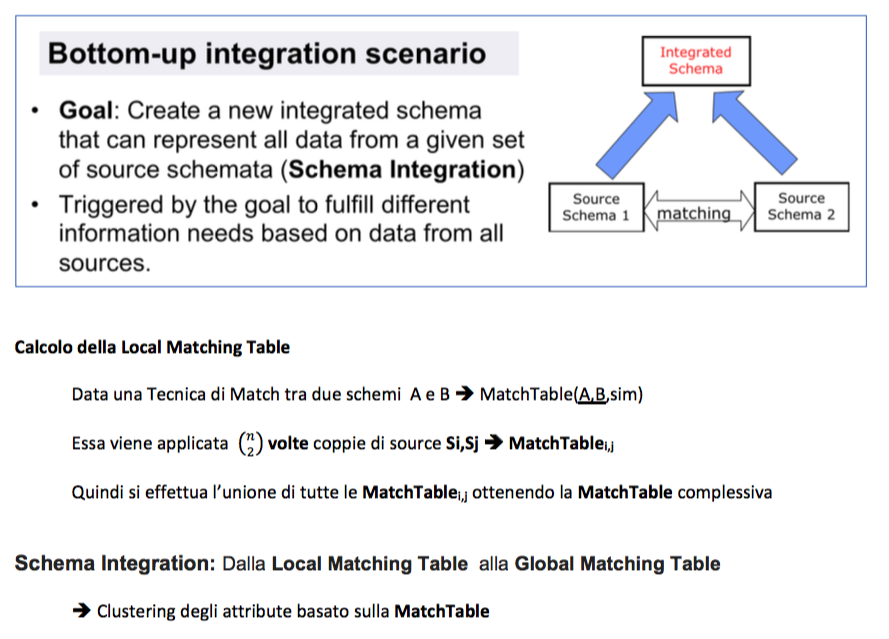

<a id="calcolo-della-local-matching-table"></a>
<a id="calcolo-della-local-matching-table"></a>
<a id="calcolo-della-local-matching-table"></a>
<a id="calcolo-della-local-matching-table"></a>
<a id="calcolo-della-local-matching-table"></a>
<a id="calcolo-della-local-matching-table"></a>
<a id="calcolo-della-local-matching-table"></a>
## Calcolo della Local Matching Table

In [85]:
def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

# Matching Methods: Qui si definiscono i Base Matcher da utilizzare; se ne possono aggiungere altri    
        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        # SimTableB = jaro_label_based_similarity(TableL, TableR)
        # SimTableB = value_overlap_sim(GlobalSchema, Sources[y])
        SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.3)

# Combined Approaches: qui si definisce il combiner; se ne possono aggiungere altri    
        SimTable = avg_sim_table([SimTableA,SimTableC])
        # SimTable = min_sim_table([SimTableA,SimTableB,SimTableC])
        # SimTable = max_sim_table([SimTableA,SimTableB])

        # Weighted-sum
        #SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )

        
# Generating Correspondences: dalla tabella di similarità alle corrispondenze

### Local Single Attribute Strategies:
        MatchTable= thresholding(SimTable, 0.3)

        #MatchTable = top_K(SimTable,2,'A')
        #MatchTable = top_K(MatchTable,2,'B')

        
### Global Mapping (si usano solo questi due metodi)
        MatchTable = stable_marriage(MatchTable)
        # MatchTable = simmetric_best_match(MatchTable)

        return MatchTable

In [86]:
def CalcoloLocalMatchingTable(Sources):
    LocalMatchingTable = pd.DataFrame(columns=['SOURCE_A', 'LAT_A', 'SOURCE_B', 'LAT_B', 'SLAT_A', 'SLAT_B', 'sim'])

    for x in Sources.keys():
        for y in Sources.keys():
            if (x < y):  

                LocalMatchingTableXY = CalcoloMatchingTable(Sources[x], Sources[y])

                print(x,y,len(LocalMatchingTableXY), end=" -- ")
                # si ottiene LocalMatchingTableXY , si rinominano gli attributi
                LocalMatchingTableXY.columns = ['LAT_A', 'LAT_B', 'sim']
                # si aggiungono i 2 nomi delle Local Sources matchate
                LocalMatchingTableXY['SOURCE_A'] = x
                LocalMatchingTableXY['SOURCE_B'] = y
                # e anche i SLAT
                LocalMatchingTableXY['SLAT_A'] = LocalMatchingTableXY['SOURCE_A'] + '_' + LocalMatchingTableXY['LAT_A']
                LocalMatchingTableXY['SLAT_B'] = LocalMatchingTableXY['SOURCE_B'] + '_' + LocalMatchingTableXY['LAT_B']
                # per poi aggiungerlo alla LocalMatchingTable complessiva
                LocalMatchingTable = LocalMatchingTable.append(LocalMatchingTableXY, sort=True)
    return LocalMatchingTable[['SOURCE_A', 'LAT_A', 'SOURCE_B', 'LAT_B', 'SLAT_A', 'SLAT_B', 'sim']]

In [87]:
# Esempio Bizer  (nel caso Bottom-Up il Global Schema non c'è!!)
SOURCES = {}
SOURCES['S1'] = pd.DataFrame(columns=['ID','Name','Vorname','Alter'])
SOURCES['S2'] = pd.DataFrame(columns=['No','Name','FirstName','Age'])

# nel GoldStandard_Bizer il GAT assume il significato di identificativo del cluster 
VALORI = [
    ['GAT', 'SOURCE', 'LAT', 'SLAT'],
    ['1', 'S1', 'ID', 'S1_ID'],
    ['1', 'S2', 'No', 'S2_No'],
    ['2', 'S1', 'Vorname', 'S1_Vorname'],
    ['2', 'S2', 'Name', 'S2_Name'],
    ['2', 'S2', 'FirstName', 'S2_FirstName'],
    ['3', 'S1', 'Alter', 'S1_Alter'],
    ['3', 'S2', 'Age', 'S2_Age']
]
header = VALORI.pop(0)
GoldStandard_Bizer = pd.DataFrame(VALORI, columns=header)
to_GMM(GoldStandard_Bizer)


SOURCE,S1,S2
GAT,,
1,[ID],[No]
2,[Vorname],"[Name, FirstName]"
3,[Alter],[Age]


In [88]:
AnalisiGlobalMatchTable(GoldStandard_Bizer,SOURCES)

1) Le seguenti SOURCE di GMT non sono definite in Sources: []
2) I seguenti SLAT di GMT non sono definiti in Sources: []
3) GAT mappati da una sola SOURCE: []
4) GAT mappati in più LAT (per ciascuna SOURCE):
   SOURCE: S2, GAT: 2, LAT diversi: 2
5) LAT mappati in più GAT (per ciascuna SOURCE):


In [90]:
# Local Matching Table data
VALORI = [
          ['SLAT_A', 'SLAT_B', ],
          ['S1_ID', 'S2_No'],
          ['S1_Name', 'S2_Name'],
          ['S1_Vorname', 'S2_Name'],
          ['S1_Alter', 'S2_Age'],
         ]
header = VALORI.pop(0)
LMT_Bizer = pd.DataFrame(VALORI, columns=header)
LMT_Bizer

,SLAT_A,SLAT_B
0,S1_ID,S2_No
1,S1_Name,S2_Name
2,S1_Vorname,S2_Name
3,S1_Alter,S2_Age


In [91]:
LAT = generaLAT(SOURCES)
LAT['SLAT'].to_list()


['S1_ID',
 'S1_Name',
 'S1_Vorname',
 'S1_Alter',
 'S2_No',
 'S2_Name',
 'S2_FirstName',
 'S2_Age']

In [92]:
generaLAT(SOURCES)['SLAT'].to_list()

['S1_ID',
 'S1_Name',
 'S1_Vorname',
 'S1_Alter',
 'S2_No',
 'S2_Name',
 'S2_FirstName',
 'S2_Age']

<a id="connected-component"></a>
<a id="connected-component"></a>
<a id="connected-component"></a>
<a id="connected-component"></a>
<a id="connected-component"></a>
<a id="connected-component"></a>
<a id="connected-component"></a>
## Connected Component

Nel seguito una definizione informale di *Componente Connesso* di un *grafo*


A connected component, of an undirected graph is a subgraph in which any two vertices are connected to each other by paths, and which is connected to no additional vertices in the supergraph.

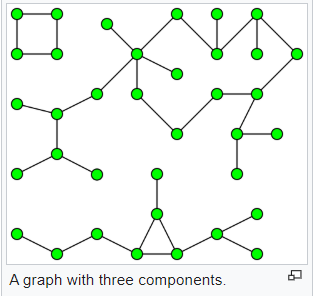

An alternative way to define components involves the equivalence classes of an equivalence relation that is defined on the vertices of the graph. In an undirected graph, a vertex v is reachable from a vertex u if there is a path from u to v. In this definition, a single vertex is counted as a path of length zero, and the same vertex may occur more than once within a path. Reachability is an equivalence relation, since:

* It is **reflexive**: There is a trivial path of length zero from any vertex to itself.

* It is **symmetric**: If there is a path from u to v, the same edges form a path from v to u.

* It is **transitive**: If there is a path from u to v and a path from v to w, the two paths may be concatenated together to form a path from u to w.

The components are then the induced subgraphs formed by the equivalence classes of this relation.



Si potrebbe utilizzare un algoritmo già sviluppato, ad esempio l'algoritmo  in
https://stackoverflow.com/questions/10301000/python-connected-components


Un'altra soluzione 
è quella di calcolare la Reflexive, Symmetric  and Transitive Closure di una relazione binaria, ovvero della MatchTable e poi effettuare un  raggruppamento,
come presentato nei notebook degli anni passati . In questo Notebook usaremo Networkx




<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
<a id="calcolo-dei-componenti-connessi-e-dei-cluster-tramite-networkx"></a>
## Calcolo dei Componenti Connessi e dei Cluster tramite **Networkx**

In [93]:
import networkx as nx
import matplotlib.pyplot as plt

In [94]:
# si parte dalla Local Matching Table 
# considriamo quella data dell'esempio Bizer
VALORI = [
          ['SLAT_A', 'SLAT_B', ],
          ['S1_ID', 'S2_No'],
          ['S1_Name', 'S2_Name'],
          ['S1_Vorname', 'S2_Name'],
          ['S1_Alter', 'S2_Age'],
         ]
header = VALORI.pop(0)
LMT_Bizer = pd.DataFrame(VALORI, columns=header)
LMT_Bizer

LMT_Bizer[['SLAT_A', 'SLAT_B']]

,SLAT_A,SLAT_B
0,S1_ID,S2_No
1,S1_Name,S2_Name
2,S1_Vorname,S2_Name
3,S1_Alter,S2_Age


In [95]:
# per calcolare i singleton

# prima si calcolano tutti i nodi, cioè tutti gli attributi locali SLAT
TuttiInodi= generaLAT(SOURCES)['SLAT'].to_list()
# prima si calcolano tutti i nodi, cioè tutti gli attributi locali SLAT
# e qiondi i singleton per differenza
Singleton = set(TuttiInodi) - set(LMT_Bizer['SLAT_A']).union(set(LMT_Bizer['SLAT_B']))
Singleton

{'S2_FirstName'}

In [96]:
# Creazione del grafo a partire dagli elementi della LMT
G = nx.Graph()
for _, row in LMT_Bizer.iterrows():
        G.add_edge(row['SLAT_A'], row['SLAT_B'])

# Aggiungi gli elementi singleton all'insieme dei nodi
for element in Singleton:
        G.add_node(element)

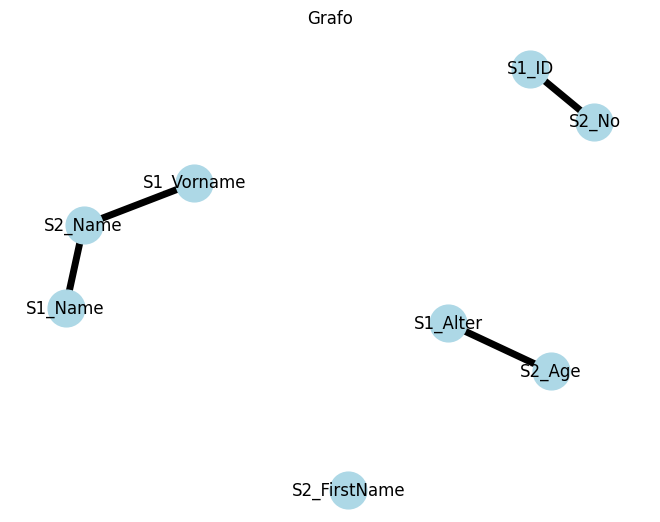

In [97]:
import matplotlib.pyplot as plt
import networkx as nx
# Posizione nodi
pos = nx.spring_layout(G, seed=42, k=0.7)
# Spessore archi (usa 1 se il peso non è definito)
weights = [d.get('weight', 1) * 5 for _, _, d in G.edges(data=True)]
# Disegna il grafo
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', width=weights)
plt.axis('off')
plt.title("Grafo")
plt.tight_layout()
plt.show()

In [98]:
# Calcola i componenti connessi (clusters)
clusters = list(nx.connected_components(G))
clusters

[{'S1_ID', 'S2_No'},
 {'S1_Name', 'S1_Vorname', 'S2_Name'},
 {'S1_Alter', 'S2_Age'},
 {'S2_FirstName'}]

In [99]:
# Creazione del DataFrame dei cluster
cluster_data = {'ClusterKey': [], 'ClusterElement': []}
for i, cluster in enumerate(clusters):
        for element in cluster:
            cluster_data['ClusterKey'].append(i + 1)
            cluster_data['ClusterElement'].append(element)

cluster_df = pd.DataFrame(cluster_data)
cluster_df

,ClusterKey,ClusterElement
0,1,S1_ID
1,1,S2_No
2,2,S1_Vorname
3,2,S2_Name
4,2,S1_Name
5,3,S2_Age
6,3,S1_Alter
7,4,S2_FirstName


In [100]:
LAT = generaLAT(SOURCES)
LAT

,SOURCE,LAT,SLAT
0,S1,ID,S1_ID
1,S1,Name,S1_Name
2,S1,Vorname,S1_Vorname
3,S1,Alter,S1_Alter
4,S2,No,S2_No
5,S2,Name,S2_Name
6,S2,FirstName,S2_FirstName
7,S2,Age,S2_Age


In [101]:
# effettuo join con gli attributi locali LAT ed ottengo la Global Matching Table GMT
LAT = generaLAT(SOURCES)
GMT=pd.merge(cluster_df,LAT, \
      left_on='ClusterElement', right_on='SLAT'). \
       rename(columns={'ClusterKey': 'GAT'}). \
            drop(columns='ClusterElement')
GMT

,GAT,SOURCE,LAT,SLAT
0,1,S1,ID,S1_ID
1,1,S2,No,S2_No
2,2,S1,Vorname,S1_Vorname
3,2,S2,Name,S2_Name
4,2,S1,Name,S1_Name
5,3,S2,Age,S2_Age
6,3,S1,Alter,S1_Alter
7,4,S2,FirstName,S2_FirstName


In [102]:
to_GMM(GMT)

SOURCE,S1,S2
GAT,,
1,[ID],[No]
2,"[Vorname, Name]",[Name]
3,[Alter],[Age]
4,[],[FirstName]


In [103]:
# I passaggi precedenti sono messi nella funzione ClusterComponentiConnessi

def ClusterComponentiConnessi(LMT, Sources):

    MatchTable = LMT.iloc[:, :2].copy()
    MatchTable.columns = ['SLAT_A', 'SLAT_B']
    

    TuttiInodi= generaLAT(SOURCES)['SLAT'].to_list()
    Singleton = set(TuttiInodi) - set(MatchTable['SLAT_A']).union(set(MatchTable['SLAT_B']))


    # Creazione del grafo a partire dagli elementi della MatchTable
    G = nx.Graph()
    for _, row in MatchTable.iterrows():
        G.add_edge(row['SLAT_A'], row['SLAT_B'])

    # Aggiungi gli elementi singleton all'insieme dei nodi
    for element in Singleton:
        G.add_node(element)

    # Calcola i componenti connessi (clusters)
    clusters = list(nx.connected_components(G))

    # Creazione del DataFrame dei cluster
    cluster_data = {'ClusterKey': [], 'ClusterElement': []}
    for i, cluster in enumerate(clusters):
        for element in cluster:
            cluster_data['ClusterKey'].append(i + 1)
            cluster_data['ClusterElement'].append(element)

    cluster_df = pd.DataFrame(cluster_data)
    return cluster_df

In [104]:
ClusterComponentiConnessi(LMT_Bizer,SOURCES)

,ClusterKey,ClusterElement
0,1,S1_ID
1,1,S2_No
2,2,S1_Vorname
3,2,S2_Name
4,2,S1_Name
5,3,S2_Age
6,3,S1_Alter
7,4,S2_FirstName


In [105]:
def GMTComponentiConnessi(LocalMatchingTable, Sources):
    
    Cluster=ClusterComponentiConnessi(LocalMatchingTable,Sources)
    LAT = generaLAT(Sources)
    
    GMT=pd.merge(Cluster,LAT, \
      left_on='ClusterElement', right_on='SLAT'). \
       rename(columns={'ClusterKey': 'GAT'}). \
            drop(columns='ClusterElement')

    return GMT

In [106]:
GMTComponentiConnessi(LMT_Bizer,SOURCES)

,GAT,SOURCE,LAT,SLAT
0,1,S1,ID,S1_ID
1,1,S2,No,S2_No
2,2,S1,Vorname,S1_Vorname
3,2,S2,Name,S2_Name
4,2,S1,Name,S1_Name
5,3,S2,Age,S2_Age
6,3,S1,Alter,S1_Alter
7,4,S2,FirstName,S2_FirstName


In [107]:
to_GMM(GMTComponentiConnessi(MatchTable_Bizer,SOURCES))

SOURCE,S1,S2
GAT,,
1,[],[Name]
2,[],[Age]
3,[],[FirstName]
4,[Alter],[]
5,[],[No]
6,[Vorname],[]
7,[ID],[]
8,[Name],[]


In [108]:
# definisco una funzione complessiva

def SchemaIntegration(Sources):

    LMT = CalcoloLocalMatchingTable(Sources)[['SLAT_A','SLAT_B']]
    
    GMT = GMTComponentiConnessi(LMT,Sources)
    

    return to_GMM(GMT)

In [113]:
# che verrà chiamata dopo aver definito il metodo di match tra due tabelle

def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

# Matching Methods: Qui si definiscono i Base Matcher da utilizzare; se ne possono aggiungere altri    
        SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        SimTableB = jaro_label_based_similarity(TableL, TableR)
        #SimTableB = value_overlap_sim(GlobalSchema, Sources[y])
        #SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.7)

# Combined Approaches: qui si definisce il combiner; se ne possono aggiungere altri    
        # SimTable = avg_sim_table([SimTableA,SimTableB,SimTableC])
        SimTable = avg_sim_table([SimTableA,SimTableB])
        # SimTable = max_sim_table([SimTableA,SimTableB,SimTableC])

        # Weighted-sum
        #SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )

        
# Generating Correspondences: dalla tabella di similarità alle corrispondenze

### Local Single Attribute Strategies:
        MatchTable= thresholding(SimTable, 0.4) # >> soglia -> cluster piú piccoli

        #MatchTable = top_K(SimTable,2,'A')
        #MatchTable = top_K(MatchTable,2,'B')

        
### Global Mapping (si usano solo questi due metodi)
        #MatchTable = stable_marriage(MatchTable)
        # MatchTable = simmetric_best_match(MatchTable)

        return MatchTable
SchemaIntegration(SOURCES)

S1 S2 6 -- 

SOURCE,S1,S2
GAT,,
1,"[Alter, Name]","[Name, Age, No]"
2,[Vorname],[FirstName]
3,[ID],[]


<a id="valutazione-dei-clustering-ottenuti-match-indotti"></a>
<a id="valutazione-dei-clustering-ottenuti-match-indotti"></a>
<a id="valutazione-dei-clustering-ottenuti-match-indotti"></a>
<a id="valutazione-dei-clustering-ottenuti-match-indotti"></a>
<a id="valutazione-dei-clustering-ottenuti-match-indotti"></a>
<a id="valutazione-dei-clustering-ottenuti-match-indotti"></a>
## Valutazione dei clustering ottenuti: Match Indotti


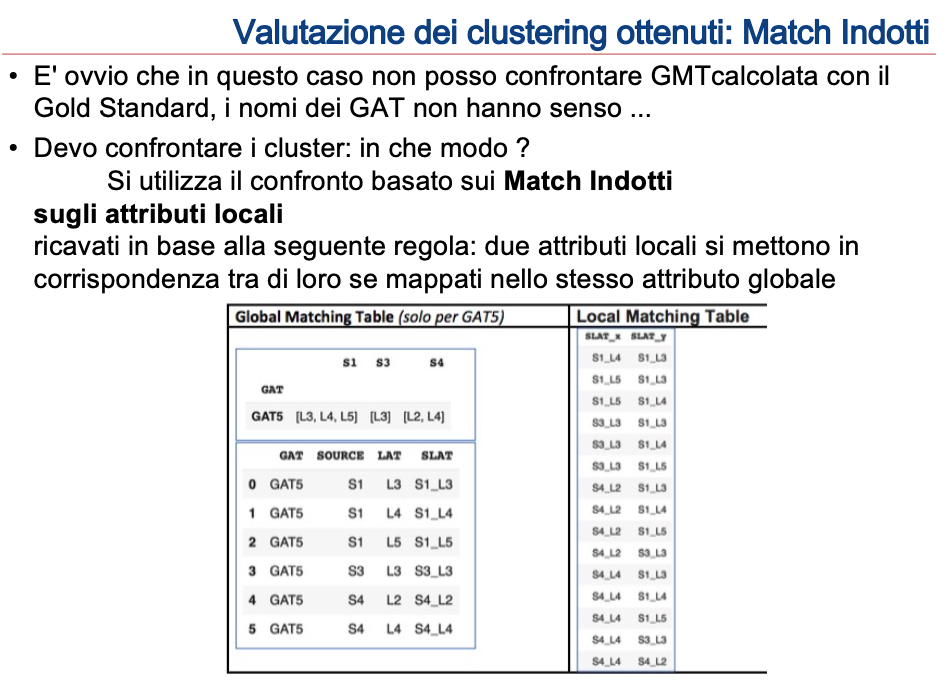


In [114]:
def MatchIndottiGMT(GMT):
  Join=pd.merge(GMT,GMT, on='GAT')
  Join=Join[Join.SOURCE_x<Join.SOURCE_y]
  Join=Join[['SLAT_x','SLAT_y']]
  Join.columns=['SLAT_A','SLAT_B']

  return Join.drop_duplicates()

In [115]:

# Esempio Bizer  (nel caso Bottom-Up il Global Schema non c'è!!)
SOURCES = {}
SOURCES['S1'] = pd.DataFrame(columns=['ID','Name','Vorname','Alter'])
SOURCES['S2'] = pd.DataFrame(columns=['No','Name','FirstName','Age'])

# nel GoldStandard_Bizer il GAT assume il significato di identificativo del cluster 
VALORI = [
    ['GAT', 'SOURCE', 'LAT', 'SLAT'],
    ['1', 'S1', 'ID', 'S1_ID'],
    ['1', 'S2', 'No', 'S2_No'],
    ['2', 'S1', 'Vorname', 'S1_Vorname'],
    ['2', 'S2', 'Name', 'S2_Name'],
    ['2', 'S2', 'FirstName', 'S2_FirstName'],
    ['3', 'S1', 'Alter', 'S1_Alter'],
    ['3', 'S2', 'Age', 'S2_Age']
]
header = VALORI.pop(0)
GMT_GoldStandard = pd.DataFrame(VALORI, columns=header)
GMT_GoldStandard

,GAT,SOURCE,LAT,SLAT
0,1,S1,ID,S1_ID
1,1,S2,No,S2_No
2,2,S1,Vorname,S1_Vorname
3,2,S2,Name,S2_Name
4,2,S2,FirstName,S2_FirstName
5,3,S1,Alter,S1_Alter
6,3,S2,Age,S2_Age


In [117]:
MatchIndottiGMT(GMT_GoldStandard)

,SLAT_A,SLAT_B
1,S1_ID,S2_No
5,S1_Vorname,S2_Name
6,S1_Vorname,S2_FirstName
14,S1_Alter,S2_Age


In [116]:
# Local Matching Table  data
VALORI = [
          ['SLAT_A', 'SLAT_B', ],
          ['S1_ID', 'S2_No'],
          ['S1_Name', 'S2_Name'],
          ['S1_Vorname', 'S2_Name'],
          ['S1_Alter', 'S2_Age'],
         ]
header = VALORI.pop(0)
LMT_Bizer = pd.DataFrame(VALORI, columns=header)

GMT_Calcolata=GMTComponentiConnessi(LMT_Bizer,SOURCES)
GMT_Calcolata

,GAT,SOURCE,LAT,SLAT
0,1,S1,ID,S1_ID
1,1,S2,No,S2_No
2,2,S1,Vorname,S1_Vorname
3,2,S2,Name,S2_Name
4,2,S1,Name,S1_Name
5,3,S2,Age,S2_Age
6,3,S1,Alter,S1_Alter
7,4,S2,FirstName,S2_FirstName


In [118]:
MatchIndottiGMT(GMT_Calcolata)

,SLAT_A,SLAT_B
1,S1_ID,S2_No
5,S1_Vorname,S2_Name
11,S1_Name,S2_Name
15,S1_Alter,S2_Age


In [119]:
Valuta(MatchIndottiGMT(GMT_GoldStandard),MatchIndottiGMT(GMT_Calcolata))

,MT,TP,FP,FN,P,R,F
0,4,3,1,1,0.75,0.75,0.75


In [120]:
Vedi_Valuta(MatchIndottiGMT(GMT_GoldStandard),MatchIndottiGMT(GMT_Calcolata),'FP')

,A,B,_merge
4,S1_Name,S2_Name,right_only


In [121]:
Vedi_Valuta(MatchIndottiGMT(GMT_GoldStandard),MatchIndottiGMT(GMT_Calcolata),'FN')

,A,B,_merge
2,S1_Vorname,S2_FirstName,left_only


<a id="esempio-bottom-up-movie"></a>
<a id="esempio-bottom-up-movie"></a>
<a id="esempio-bottom-up-movie"></a>
<a id="esempio-bottom-up-movie"></a>
<a id="esempio-bottom-up-movie"></a>
<a id="esempio-bottom-up-movie"></a>
## Esercizio Movie: BottomUp

Si considerano alcuni dataset disponibili in Magellan

https://sites.google.com/site/anhaidgroup/useful-stuff/the-magellan-data-repository


(oppure
[http://pages.cs.wisc.edu/~anhai/data/784_data/](http://pages.cs.wisc.edu/~anhai/data/784_data/))


Ogni dataset, quale ad esempio *movie5*
```
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv',
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/roger_ebert.csv',
```

è costituito da due file csv utilizzati per il processo di Entity Resolution del corso di  Anhai Doan (si noti infatti che tra i file forniti c'è anche un labelled_data che verrà usato per l'Entity Resolution basata su Machine Learning).

Questi due dataset dello stesso progetto movie5,
sono di fonti differenti (imdb e roger_ebert) ma comunque sono stati scelti in modo da avere delle sovrapposizioni, cioè uno stesso film presente in entrambi. Questa è una considerazione importante, in quanto si  può supporre che tra alcune coppie di attributi dei due differenti file ci sia un overlap che possiamo sfruttare nei metodi di Instance-based schema matching : Value Overlap


D'altra parte si nota che la stessa fonte, ad esempio imdb, è utilizzata
in differenti dataset/progetti movie5, movie3, movie1

```
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv',
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies3/csv_files/imdb.csv',
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/imdb.csv']
```

Gli attributi e le istanze sono differenti,


```
movie 5 Source: IMDB                                                             
    Number of records: 6913                                                    
    Attributes: [id, movie_name, year, directors, actors, movie_rating, genre,
                 duration]

movie 3     Source: IMDB                                                  
    Number of records: 2960                                                     
    Attributes: [ID, Title, Year, Rating, Director, Creators, Cast, Genre,
                 Duration, ContentRating, Summary]  

```


ma anche qui si può ipotizzare una certa sovrapposizione essendo la stessa fonte.

In definitiva, in questo esempio l'applicazione dei metodi di schema matching basati sulle istanze sembra essere promettente;
d'altra parte verificheremo i metodi introdotti, anche quello basato sul similarity join, richiedono un tempo di esecuzione considerevole.

Per questo motivo, il passo successivo sara' quello di introdurre un nuovo metodo sempre basato sulle istanze ma che usa tecniche di machine learning

In [122]:
src_links = [
    'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv',
    'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/roger_ebert.csv',
    'http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/rotten_tomatoes.csv',
    'http://pages.cs.wisc.edu/~anhai/data/784_data/movies3/csv_files/rotten_tomatoes.csv',
    'http://pages.cs.wisc.edu/~anhai/data/784_data/movies4/csv_files/amazon.csv',
    'http://pages.cs.wisc.edu/~anhai/data/784_data/movies3/csv_files/imdb.csv',
    'http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/imdb.csv']
SOURCES = { 'S'+str(i+1) : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }

GoldStandard=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/Movie_MTGS.csv')

to_GMM(GoldStandard)

SOURCE,0,1,2,3,4,5,6
GAT,,,,,,,
Filming_Locations,[],[],[Filming Locations],[],[],[],[]
Id,[],[],[Id],[],[],[],[Id]
RatingCount,[],[],[RatingCount],[],[],[],[]
ReviewCount,[],[],[ReviewCount],[],[],[],[]
movie_ContentRating,[],[pg_rating],[],[ContentRating],[],[ContentRating],[ContentRating]
movie_cast,[actors],[actors],"[Actors, Cast]",[Cast],[star],[Cast],[Cast]
movie_cost,[],[],[],[],[cost],[],[]
movie_country,[],[],[Country],[],[],[],[]
movie_creators,[],[],[Creator],[Creators],[],[Creators],[Creator]


In [123]:
#Nel GoldStandard questa volta le source sono indicate con 0,1,2 invece che con S1,S2, S3, ... quindi cambiamo le chiavi del dizionario SOURCES

SOURCES = { str(i) : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }

GoldStandard=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/MovieMTGS.csv')
GoldStandard['SOURCE']=GoldStandard['SOURCE'].apply(str)


In [124]:
SOURCES={}
SOURCES['0']=pd.read_csv('https://dbgroup.ing.unimore.it/SIWS/DataIntegration/4Movie/Movie0.csv').astype(str)
SOURCES['1']=pd.read_csv('https://dbgroup.ing.unimore.it/SIWS/DataIntegration/4Movie/Movie1.csv').astype(str)
SOURCES['2']=pd.read_csv('https://dbgroup.ing.unimore.it/SIWS/DataIntegration/4Movie/Movie2.csv').astype(str)
SOURCES['3']=pd.read_csv('https://dbgroup.ing.unimore.it/SIWS/DataIntegration/4Movie/Movie3.csv').astype(str)


GMT_GoldStandard=pd.read_csv('https://dbgroup.ing.unimore.it/SIWS/DataIntegration/4Movie/GoldStandard4movie.csv').astype(str)

In [125]:
to_GMM(GMT_GoldStandard)

SOURCE,0,1,2,3
GAT,,,,
movie_ContentRating,[],[pg_rating],[],[ContentRating]
movie_cast,[actors],[actors],"[Actors, Cast]",[Cast]
movie_creators,[],[],[Creator],[Creators]
movie_director,[directors],[directors],[Director],[Director]
movie_genre,[genre],[genre],[Genre],[Genre]
movie_rating,[movie_rating],[critic_rating],[RatingValue],[Rating]
movie_title,[movie_name],[movie_name],[Name],[Title]
movie_year,[year],[year],[Year],[Year]


In [126]:
AnalisiGlobalMatchTable(GMT_GoldStandard,SOURCES)

1) Le seguenti SOURCE di GMT non sono definite in Sources: []
2) I seguenti SLAT di GMT non sono definiti in Sources: []
3) GAT mappati da una sola SOURCE: []
4) GAT mappati in più LAT (per ciascuna SOURCE):
   SOURCE: 2, GAT: movie_cast, LAT diversi: 2
5) LAT mappati in più GAT (per ciascuna SOURCE):


In [127]:
# definiamo il calcolo della Matching table

def CalcoloMatchingTable(TableL:pd.DataFrame,TableR:pd.DataFrame):

        #SimTableA = levenshtein_label_based_similarity(TableL, TableR)
        #SimTableB = jaro_label_based_similarity(TableL, TableR)
        #SimTableB = value_overlap_sim(GlobalSchema, Sources[y])
        SimTableC=value_overlap_simjoin_jaccard(TableL, TableR, 0.2)

        # combiner
        # SimTable = avg_sim_table([SimTableA,SimTableB,SimTableC])
        # SimTable = min_sim_table([SimTableA,SimTableB,SimTableC])
        SimTable = max_sim_table([SimTableC])

        # Weighted-sum
        # SimTable = Weighted_sum([SimTableA,SimTableB,SimTableC], [.3,.4,.3] )


        # dalla tabella di similarità alle corrispondenze

        MatchTable= thresholding(SimTable, 0.5)

        # MatchTable = top_K(SimTable,2,'A')
        MatchTable = top_K(MatchTable,2, 'B')

         # global mapping
        #MatchTable = stable_marriage(MatchTable)
        #MatchTable = simmetric_best_match(MatchTable)

        return MatchTable

In [129]:
GMMcalcolata=SchemaIntegration(SOURCES)
GMMcalcolata

0 1 5 -- 0 2 6 -- 0 3 6 -- 1 2 7 -- 1 3 9 -- 2 3 9 -- 

SOURCE,0,1,2,3
GAT,,,,
1,"[movie_rating, year]","[year, critic_rating]","[Year, RatingValue]","[Year, Rating]"
2,[directors],[directors],"[Creator, Director]","[Director, Creators]"
3,[genre],[genre],[Genre],[Genre]
4,[movie_name],[movie_name],[Name],[Title]
5,[],[pg_rating],[],[ContentRating]
6,[],[],[Cast],[]
7,[],[actors],[],[]
8,[],[],[],[Cast]
9,[actors],[],[],[]


In [130]:
GMT_Calcolata=to_GMT(GMMcalcolata)
AnalisiGlobalMatchTable(GMT_Calcolata,SOURCES)

1) Le seguenti SOURCE di GMT non sono definite in Sources: []
2) I seguenti SLAT di GMT non sono definiti in Sources: []
3) GAT mappati da una sola SOURCE: [6, 7, 8, 9, 10]
4) GAT mappati in più LAT (per ciascuna SOURCE):
   SOURCE: 0, GAT: 1, LAT diversi: 2
   SOURCE: 1, GAT: 1, LAT diversi: 2
   SOURCE: 2, GAT: 1, LAT diversi: 2
   SOURCE: 2, GAT: 2, LAT diversi: 2
   SOURCE: 3, GAT: 1, LAT diversi: 2
   SOURCE: 3, GAT: 2, LAT diversi: 2
5) LAT mappati in più GAT (per ciascuna SOURCE):


In [131]:
Valuta(MatchIndottiGMT(GMT_GoldStandard),MatchIndottiGMT(GMT_Calcolata))

,MT,TP,FP,FN,P,R,F
0,50,32,18,9,0.64,0.7805,0.7033
